In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

from tqdm import tqdm
from stable_baselines3 import DQN
from environment.shared_core_config import make_env
from src.utils.evaluate import evaluate_policy

c:\Users\clemm\miniconda3\envs\project-rl-env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [ ]:
def extract_metrics(model_path, use_safety=False, penalty_weight=0.0, density=1.0, num_episodes=50):
    env = make_env(use_safety_wrapper=use_safety, penalty_weight=penalty_weight)
    env.unwrapped.configure({"vehicles_density": density})
    
    model = DQN.load(model_path)
        
    def policy(obs):
        action, _ = model.predict(obs, deterministic=True)
        if isinstance(action, np.ndarray):
            action = action.item()
        return action
        
    ep_rews, ep_lens, mean_rew, std_rew, crash_rate, fail_seeds, mean_speed = evaluate_policy(
        env, policy, num_episodes=num_episodes, speed=True
    )
    
    env.close()
    return crash_rate, mean_speed

In [3]:
BASELINE_MODEL = "results/sb3/sb3_seed_1_last.zip"
SAFETY_MODEL = "results/sb3_safety/penalty_1.0/sb3_seed_1_last.zip"

base_crash_rate, base_speed = extract_metrics(BASELINE_MODEL, use_safety=False, num_episodes=50)
safe_crash_rate, safe_speed = extract_metrics(SAFETY_MODEL, use_safety=True, penalty_weight=1.0, num_episodes=50)


Evaluating policy: 100%|██████████| 50/50 [26:52<00:00, 32.24s/it]


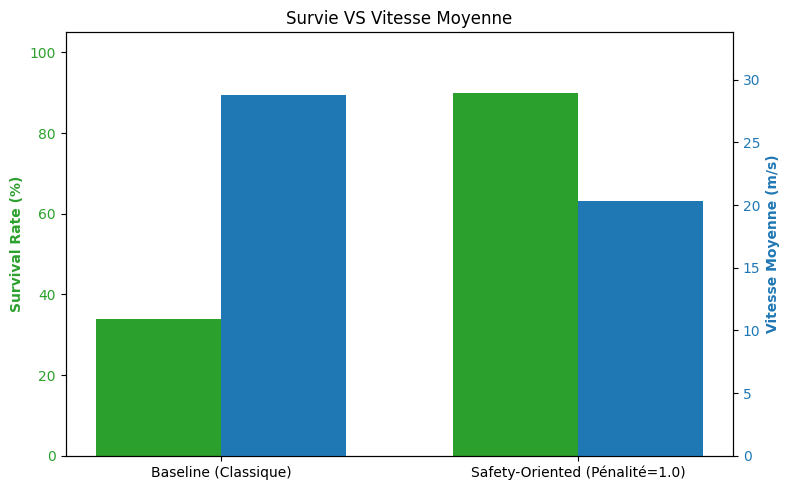

[BASELINE] Crash Rate: 66.0% | Avg Speed: 28.77 m/s
[SAFETY]   Crash Rate: 10.0% | Avg Speed: 20.35 m/s


In [4]:
labels = ['Baseline (Classique)', 'Safety-Oriented (Pénalité=1.0)']
survival_rates = [100 - base_crash_rate, 100 - safe_crash_rate]
speeds = [base_speed, safe_speed]

x = np.arange(len(labels))
width = 0.35  

fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = 'tab:green'
ax1.set_ylabel('Survival Rate (%)', color=color1, fontweight='bold')
ax1.bar(x - width/2, survival_rates, width, label='Survival Rate', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim([0, 105])

ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Vitesse Moyenne (m/s)', color=color2, fontweight='bold')
ax2.bar(x + width/2, speeds, width, label='Average Speed', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim([0, max(max(speeds)+5, 30)])

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
plt.title("Survie VS Vitesse Moyenne")
fig.tight_layout()
plt.show()

print(f"[BASELINE] Crash Rate: {base_crash_rate:.1f}% | Avg Speed: {base_speed:.2f} m/s")
print(f"[SAFETY]   Crash Rate: {safe_crash_rate:.1f}% | Avg Speed: {safe_speed:.2f} m/s")

Evaluating policy: 100%|██████████| 20/20 [02:29<00:00,  7.47s/it]


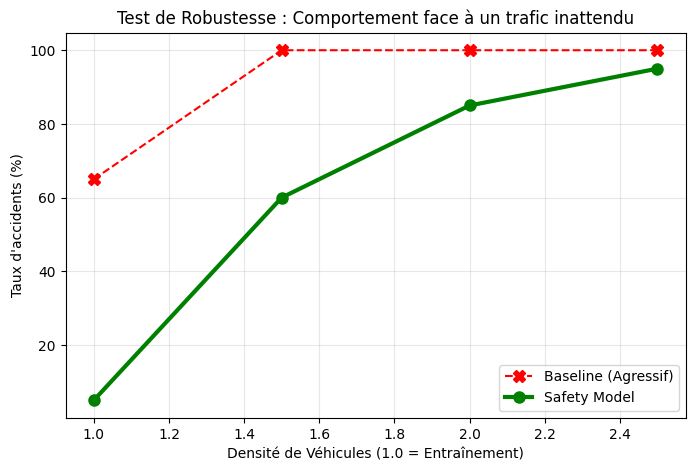

In [5]:
densities = [1.0, 1.5, 2.0, 2.5]
base_crashes_density = []
safe_crashes_density = []

for d in densities:
    c_rate, _ = extract_metrics(BASELINE_MODEL, use_safety=False, density=d, num_episodes=20)
    base_crashes_density.append(c_rate)
    
    s_rate, _ = extract_metrics(SAFETY_MODEL, use_safety=True, penalty_weight=1.0, density=d, num_episodes=20)
    safe_crashes_density.append(s_rate)

plt.figure(figsize=(8, 5))
plt.plot(densities, base_crashes_density, marker='X', color='red', linestyle='dashed', markersize=8, label='Baseline (Agressif)')
plt.plot(densities, safe_crashes_density, marker='o', color='green', linewidth=3, markersize=8, label='Safety Model')

plt.title("Test de Robustesse : Comportement face à un trafic inattendu")
plt.xlabel("Densité de Véhicules (1.0 = Entraînement)")
plt.ylabel("Taux d'accidents (%)")
plt.grid(visible=True, alpha=0.3)
plt.legend()
plt.show()

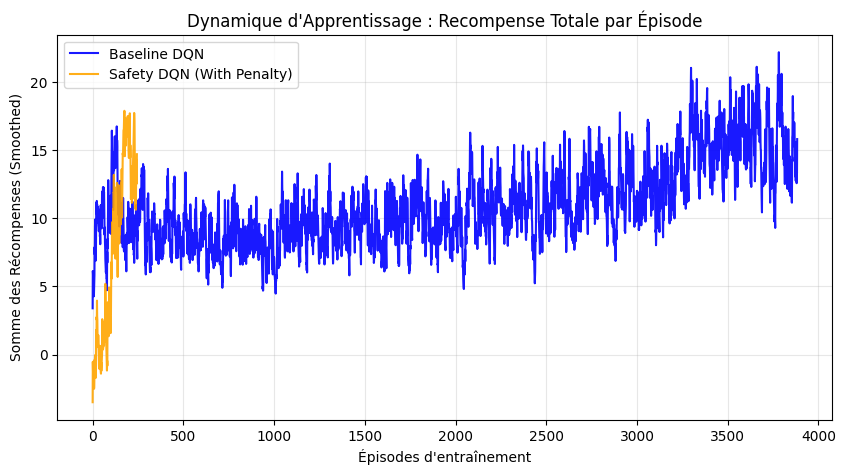

In [6]:
def smooth_rewards(scalars, weight=0.85):
    if len(scalars) == 0: return []
    last = scalars[0]
    smoothed = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

baseline_rewards_path = "results/sb3/sb3_seed_1_rewards.npy"
safety_rewards_path = "results/sb3_safety/penalty_1.0/sb3_seed_1_rewards.npy"

base_rewards = np.load(baseline_rewards_path)
safe_rewards = np.load(safety_rewards_path)

base_rewards_smoothed = smooth_rewards(base_rewards)
safe_rewards_smoothed = smooth_rewards(safe_rewards)

plt.figure(figsize=(10, 5))
plt.plot(base_rewards_smoothed, label="Baseline DQN", color='blue', alpha=0.9)
plt.plot(safe_rewards_smoothed, label="Safety DQN (With Penalty)", color='orange', alpha=0.9)

plt.title("Dynamique d'Apprentissage : Recompense Totale par Épisode")
plt.xlabel("Épisodes d'entraînement")
plt.ylabel("Somme des Récompenses (Smoothed)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()